# House Pricing in Tehran: Regression Project

## Phase 2: Exploratory Data Analysis (EDA) & Regression Modeling

In this phase, we utilize the refined dataset — **`housePrice_cleaned.csv`** — generated from the initial cleaning phase. Our goal is to analyze the relationships between features and develop a machine learning model to predict housing prices in Tehran.

---

### 1. Statistical Distribution Analysis
* **Area Insights:** We examine the distribution of properties within the **0 to 250 $m^2$** range to understand the most common market segments.
* **Price Distribution:** Checking for skewness in `Price` to determine if a logarithmic transformation is required for better model linearity.

---

### 2. Market Analysis: Price vs. Location & Area

we perform a comprehensive **Exploratory Data Analysis (EDA)** on housing data to understand the factors influencing property valuations. The analysis is structured into three main phases:

#### 1. Statistical Distribution Analysis
The first step involves examining the underlying distribution of our core variables: **Area** and **Price**.
* Using **Histograms** and **KDE** plots to identify skewness.
* Detecting potential outliers and evaluating the need for data transformation (e.g., Log Scaling).
* Assessing if the target variable follows a normal distribution for future modeling.

#### 2. Bivariate Correlation: Area vs. Price
We explore the direct relationship between a property's physical size and its market value.
* Utilizing **Scatter Plots** to visualize how price scales with square footage.
* Identifying density zones and market trends across different property sizes.

#### 3. Geographic Market Segmentation
Location is a critical driver of real estate value. We categorize and rank neighborhoods to identify market extremes:
* **Premium Market Analysis:** Identifying the top 10 most expensive neighborhoods based on average prices.
* **Affordability Analysis:** Identifying the top 10 most budget-friendly neighborhoods.
* Evaluating the price gap between different urban districts.

---

### 3. Predictive Modeling
* **Algorithm:** Implementing **Linear Regression** as our baseline model.
* **Evaluation Metrics:** Assessing performance using **$R^2$ Score** and **Mean Absolute Error (MAE)** to quantify prediction accuracy.

---
> **Data Source:** This analysis is based on the filtered dataset containing approximately 3,800+ records after removing outliers and missing addresses.

### Library Imports
We start by importing the necessary libraries for data manipulation and visualization.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns

### Reading Data
Now we load the raw dataset from the CSV file into a Pandas DataFrame to begin our initial inspection and analysis.

In [2]:
df = pd.read_csv("housePrice_cleaned.csv")

### 1. Statistical Distribution Analysis

In this step, we visualize the distribution of **Area** and **Price** to understand the dataset's characteristics and check for skewness or outliers.

After visualizing the core features of our dataset, we observe the following patterns:

* **Area Distribution (Left):**
    * The distribution is concentrated between **50 $m^2$ and 150 $m^2$**, representing the most active segment of the Tehran housing market.
    * Since we previously filtered out properties larger than **250 $m^2$**, the chart effectively displays the "Standard Residential" range without extreme luxury outliers.
    * The curve (KDE) shows a slight right-skew, but it is relatively balanced for a regression model.
* **Price Distribution (Right):**
    * The target variable (`Price`) exhibits a strong **Positive Skew (Right-Skewed)**. Most properties are clustered in the lower price range, while a few high-value properties pull the tail to the right.
    * The scale on the X-axis ($1e10$) indicates very high nominal values, which is typical for the Iranian Rial.

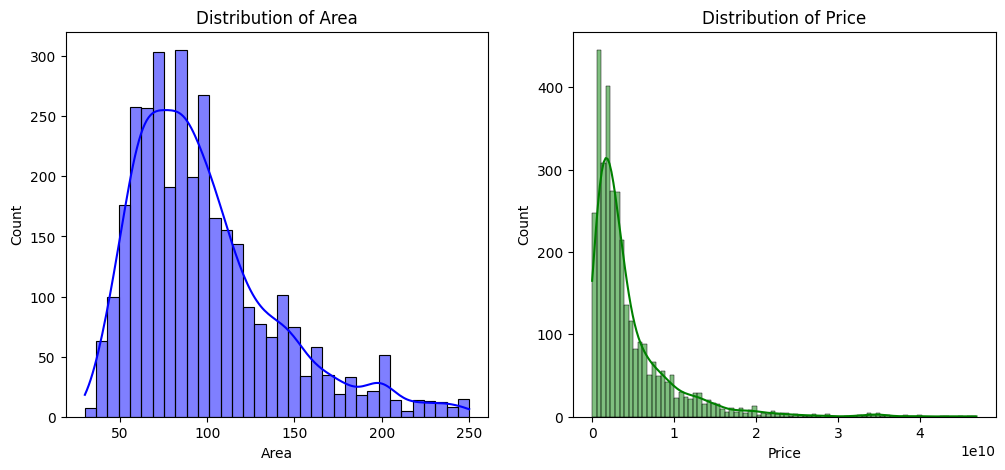

In [3]:
plt.figure(figsize=(12, 5))

# Area
plt.subplot(1, 2, 1)
sns.histplot(df['Area'], kde=True, color='blue')
plt.title('Distribution of Area')

# Price
plt.subplot(1, 2, 2)
sns.histplot(df['Price'], kde=True, color='green')
plt.title('Distribution of Price')

plt.show()

### 2. Market Analysis: Price vs. Location & Area

In this stage, we examine how property prices are influenced by physical size and geographical location.

#### 2.1. Price vs. Area Correlation Analysis

The scatter plot below illustrates the relationship between the **Living Area** (in square meters) and the **Property Price** (in USD).

**Key Observations:**
* **Positive Correlation:** There is a clear positive trend, indicating that as the square footage increases, the property price generally rises.
* **Price Variance:** For properties between 150 and 250 sqm, we observe a wider spread in prices, suggesting that other factors (like neighborhood or amenities) significantly impact valuation in larger homes.
* **Density:** The majority of listings are concentrated under 150 sqm with prices below $400,000.
* **Outliers:** A few data points show exceptionally high prices for relatively smaller areas, which may represent luxury listings or premium locations.

> **Conclusion:** Area is a strong predictor for price, but its influence becomes more variable as the size of the property increases.

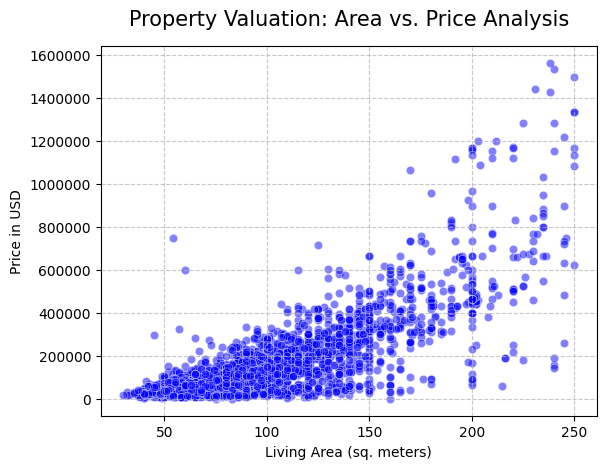

In [4]:
sns.scatterplot(data=df, x='Area', y='Price(USD)', alpha=0.5, color='blue', edgecolor='w')
plt.title('Property Valuation: Area vs. Price Analysis', fontsize=15, pad=15)
plt.xlabel('Living Area (sq. meters)')
plt.ylabel('Price in USD')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

#### 2.2. Neighborhood Price Analysis

This bar chart represents the **Top 10 Most Expensive Neighborhoods** based on their average property prices.

**Key Insights:**
* **Premium Districts:** **Elahieh** and **Velenjak** stand out as the most expensive areas, with average prices nearing or exceeding 20 billion Toman.
* **Top-Tier Clusters:** Areas such as **Zaferanieh**, **Kamranieh**, and **Farmanieh** follow closely, forming a high-end market cluster with relatively similar valuation levels.
* **Price Gradient:** There is a visible downward trend from Elahieh to Araj, showing a significant price gap even among the city's most elite neighborhoods.

> **Market Note:** The data indicates a heavy concentration of luxury real estate in these specific northern districts, where location significantly inflates the average cost per listing.

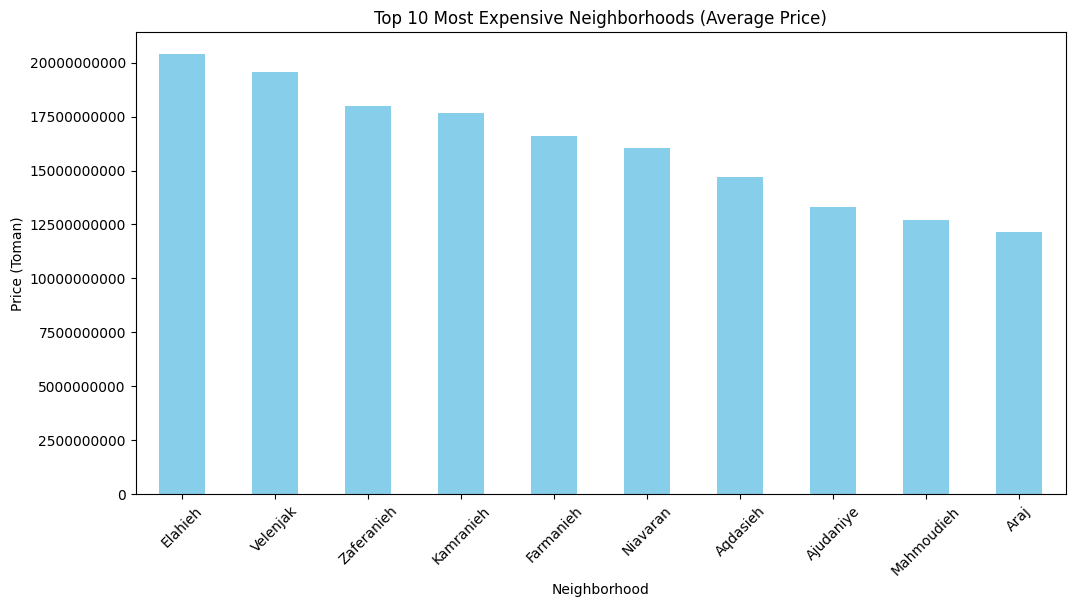

In [5]:
top_addresses = df.groupby('Address')['Price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_addresses.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Expensive Neighborhoods (Average Price)')
plt.ylabel('Price (Toman)')
plt.xlabel('Neighborhood')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.show()

#### 2.3. Affordable Neighborhood Analysis

This bar chart highlights the **Top 10 Most Affordable Neighborhoods** based on their average property prices, providing insight into the budget-friendly segment of the market.

**Key Insights:**
* **Entry-Level Markets:** **Malard** and **Robat Karim** represent the most accessible areas in the dataset, with average prices significantly lower than the city's premium districts.
* **Price Consistency:** The first three neighborhoods (Malard, Robat Karim, and Pishva) show a relatively stable price floor, making them primary options for budget-conscious buyers.
* **Growth Trend:** There is a steady upward trend in average prices as we move towards areas like **Naziabad**, which acts as a bridge between the most affordable outskirts and mid-range urban neighborhoods.

> **Market Note:** While these areas offer much lower entry costs, the trade-off often involves greater distance from the city center or different levels of local infrastructure compared to high-end districts.

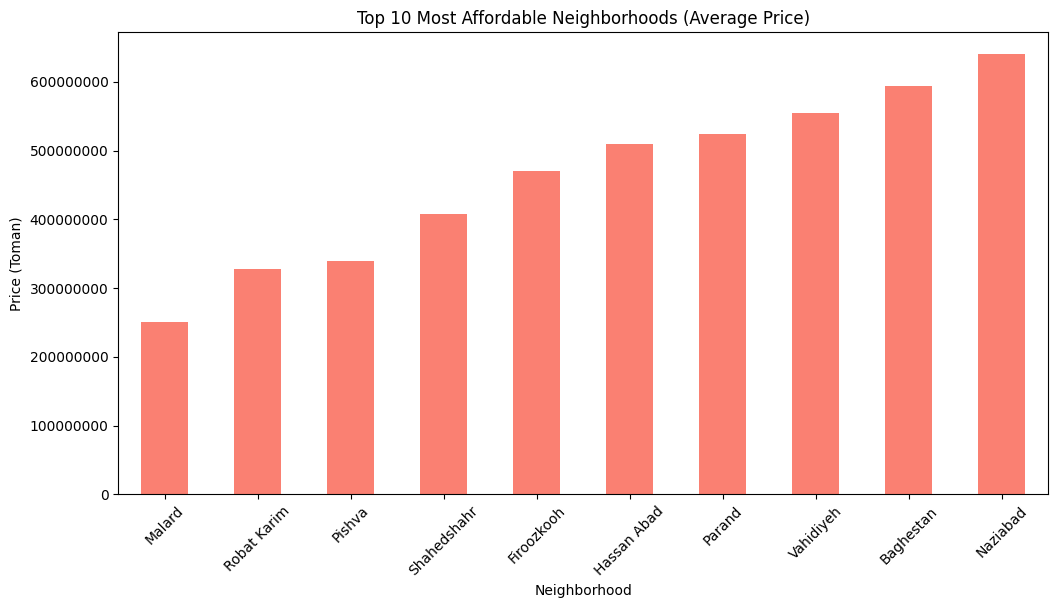

In [6]:
top_addresses = df.groupby('Address')['Price'].mean().sort_values(ascending=True).head(10)

plt.figure(figsize=(12, 6))
top_addresses.plot(kind='bar', color='salmon')
plt.title('Top 10 Most Affordable Neighborhoods (Average Price)')
plt.ylabel('Price (Toman)')
plt.xlabel('Neighborhood')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.show()

#### Currency Conversion & Exchange Rate Estimation

Since the dataset contains prices in both USD and Toman, we use a **Linear Regression** model to mathematically determine the exchange rate used in the data.

##### **Mathematical Model**
The relationship between the two currencies is modeled using the linear equation:
$$Price_{(Toman)} = \beta_1 \cdot Price_{(USD)} + \beta_0$$

Where:
* $\beta_1$ (Slope) represents the **Estimated Exchange Rate**.
* $\beta_0$ (Intercept) represents the base offset (ideally close to zero).

##### **Analysis Results**
Based on the regression fit, the derived formula is:
> **Price = (30,000.00 × Price_USD) - 3.93**

This indicates that the dataset uses a fixed exchange rate of approximately **30,000 Toman per USD**.

In [7]:
def convert_USD_TO_TOMAN(USD_price):

    from sklearn.linear_model import LinearRegression

    # Build & Train Model
    X = df[['Price(USD)']]
    y = df['Price']
    reg = LinearRegression()
    reg.fit(X, y)

    # Formula
    slope = reg.coef_[0]
    intercept = reg.intercept_
    Rial_price = slope * USD_price + intercept
    
    return Rial_price

### 3.1. Machine Learning: Price Prediction Model

In this stage, we transition from exploration to **Predictive Modeling**. We utilize a **Random Forest Regressor**, which is an ensemble learning method highly effective for real estate data due to its ability to handle non-linear relationships.

#### **Workflow:**
* **Feature Encoding:** Converting categorical 'Address' labels into numerical values to make them compatible with the model.
* **Data Splitting:** Partitioning the dataset into **80% Training** and **20% Testing** to validate the model's ability to generalize on unseen data.
* **Random Forest Training:** Building a forest of 100 decision trees to learn the complex interactions between features like `Area`, `Room`, and `Address`.
* **Evaluation Metrics:** Assessing performance using **R² Score** (for accuracy) and **Mean Absolute Error (MAE)** to quantify the average prediction deviation in Toman.

> **Objective:** To build a robust model capable of estimating property values with high precision based on physical and geographical attributes.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


# Convert 'Address' text data into numerical format using LabelEncoder
le = LabelEncoder()
df['Address_Encoded'] = le.fit_transform(df['Address'])


# Splitting the data into Training (80%) and Testing (20%) sets using a random mask
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]


# Defining independent variables (X) and the dependent variable (y) for training
train_x = np.asanyarray(train[['Area', 'Room', 'Address_Encoded', 'Parking', 'Warehouse', 'Elevator']])
train_y = np.asanyarray(train[['Price(USD)']])

# Construction and Training Model
# Initializing RandomForestRegressor with 100 trees and fitting it to the training data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_x, train_y.ravel()) # .ravel() is used to convert y to a 1D array


# Preparing the test variables to evaluate model performance
test_x = np.asanyarray(test[['Area', 'Room', 'Address_Encoded', 'Parking', 'Warehouse', 'Elevator']])
test_y = np.asanyarray(test[['Price(USD)']])


# Making predictions on the test set and calculating performance metrics
y_pred = model.predict(test_x)
print(f"Accuracy (R2 Score): {r2_score(test_y, y_pred):.2f}")
print(f"Mean Error: {mean_absolute_error(test_y, y_pred):,.0f} USD")

Accuracy (R2 Score): 0.76
Mean Error: 40,741 USD


### 3.2. Real-Time Price Prediction Interface

We have developed a dedicated function, `predict_house_price`, to serve as a high-level interface for our model. This function streamlines the process of taking raw user input and generating a market estimate.

**Function Capabilities:**
* **Automated Encoding:** It automatically transforms text-based addresses into the numerical format required by the Random Forest model.
* **Feature Engineering:** It organizes input parameters (Area, Rooms, Amenities) into a structured feature vector for consistent predictions.
* **Error Handling:** Includes a `try-except` block to gracefully handle "Out-of-Vocabulary" (OOV) addresses that were not part of the original training set.
* **Dual Currency Output:** Integrates with our conversion utility to provide estimates in both USD and Toman.

> **Usage:** This function can be used to test specific real estate scenarios or integrated into a web application for real-time user queries.

In [9]:
def predict_house_price(area, room, address, parking, warehouse, elevator):

    try:
        # Encode the address text into its numerical representation
        address_encoded = le.transform([address])[0]
        
        # Construct the feature vector in the specific order expected by the model
        features = [[area, room, address_encoded, int(parking), int(warehouse), int(elevator)]]
        
        prediction = model.predict(features)
        
        return prediction[0]
    
    except ValueError:
        
        return "This neighborhood is not present in the training data and is unknown to the model."

# --- Testing the model with a new sample input ---
# Parameters: Area=110, Rooms=2, Address='Pardis', Parking=True, Warehouse=True, Elevator=True
new_price = predict_house_price(110, 2, 'Pardis', True, True, True)

if isinstance(new_price, str):
    print(new_price)
else:
    # Output the result in both USD and local currency (Toman)
    print(f"Estimated Price: {new_price:,.0f} USD")
    print(f"Estimated Price: {convert_USD_TO_TOMAN(new_price):,.0f} Toman")

Estimated Price: 19,097 USD
Estimated Price: 572,923,264 Toman
